# Covariance Spectrum Through a Depth-32 ReLU MLP

This notebook mirrors the covariance propagation logic from `examples/03_covariance_propagation.py`, but keeps the post-ReLU covariance matrix from every layer so we can inspect its spectrum as depth increases.

The covariance update is the same approximation used by the starterkit example:

- Linear step: `mu_pre = W.T @ mu`, `cov_pre = W.T @ cov @ W`
- ReLU mean and diagonal variance: exact marginal formulas
- ReLU off-diagonal covariance: `cov_post[i, j] ~= Phi(alpha_i) Phi(alpha_j) cov_pre[i, j]`

The rank summaries below are therefore summaries of this propagated covariance approximation, not empirical Monte Carlo covariances.

In [11]:
from __future__ import annotations

import math
import numpy as np

try:
    import matplotlib.pyplot as plt
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "This notebook needs matplotlib for the visualization cells. "
        "Install it in this environment with: python -m pip install matplotlib"
    ) from exc

plt.style.use("seaborn-v0_8-whitegrid")
np.set_printoptions(precision=4, suppress=True)

## Experiment Parameters

The default width matches the starterkit examples. If eigen-decompositions feel slow on your machine, lower `WIDTH` to 128 first; the depth behavior is still quite informative.

In [12]:
WIDTH = 256
DEPTH = 32
SEED = 0
COV_RESCALE_THRESHOLD = 1e100

def build_he_relu_mlp_weights(width: int, depth: int, seed: int = 0) -> list[np.ndarray]:
    rng = np.random.default_rng(seed)
    scale = math.sqrt(2.0 / width)
    return [rng.standard_normal((width, width)).astype(np.float64) * scale for _ in range(depth)]


weights = build_he_relu_mlp_weights(width=WIDTH, depth=DEPTH, seed=SEED)

print(f"Built MLP with width={WIDTH}, depth={DEPTH}, seed={SEED}")

Built MLP with width=256, depth=32, seed=0


## Covariance Propagation With Saved Layer Covariances

In [13]:
def norm_pdf(x: np.ndarray) -> np.ndarray:
    return np.exp(-0.5 * x * x) / math.sqrt(2.0 * math.pi)


def norm_cdf(x: np.ndarray) -> np.ndarray:
    # Avoid a SciPy dependency: vectorized math.erf is plenty fast for width-scale vectors.
    erf_vec = np.vectorize(math.erf, otypes=[np.float64])
    return 0.5 * (1.0 + erf_vec(x / math.sqrt(2.0)))


def propagate_covariances(weights: list[np.ndarray]) -> dict[str, np.ndarray]:
    width = weights[0].shape[0]
    mu = np.zeros(width, dtype=np.float64)
    cov = np.eye(width, dtype=np.float64)
    log_scale = 0.0

    means = []
    covariances = []
    pre_relu_covariances = []
    rescale_log_factors = []

    for layer, w in enumerate(weights, start=1):
        max_var = float(np.max(np.diag(cov)))
        if max_var > COV_RESCALE_THRESHOLD:
            s = math.sqrt(max_var)
            mu = mu / s
            cov = cov / (s * s)
            log_scale += math.log(s)

        mu_pre = w.T @ mu
        cov_pre = w.T @ cov @ w
        cov_pre = 0.5 * (cov_pre + cov_pre.T)

        var_pre = np.maximum(np.diag(cov_pre), 1e-12)
        sigma_pre = np.sqrt(var_pre)
        alpha = mu_pre / sigma_pre
        phi_alpha = norm_pdf(alpha)
        Phi_alpha = norm_cdf(alpha)

        mu = mu_pre * Phi_alpha + sigma_pre * phi_alpha
        ez2 = (mu_pre * mu_pre + var_pre) * Phi_alpha + mu_pre * sigma_pre * phi_alpha
        var_post = np.maximum(ez2 - mu * mu, 0.0)

        gain = np.where(sigma_pre > 1e-12, Phi_alpha, 0.0)
        cov = np.outer(gain, gain) * cov_pre
        np.fill_diagonal(cov, var_post)
        cov = 0.5 * (cov + cov.T)

        means.append(mu * math.exp(log_scale))
        covariances.append(cov.copy())
        pre_relu_covariances.append(cov_pre.copy())
        rescale_log_factors.append(log_scale)

    return {
        "means": np.stack(means),
        "covariances": np.stack(covariances),
        "pre_relu_covariances": np.stack(pre_relu_covariances),
        "rescale_log_factors": np.array(rescale_log_factors),
    }


results = propagate_covariances(weights)
covariances = results["covariances"]
print(covariances.shape)

(32, 256, 256)


## Eigenvalues and Rank Summaries

`eigh` is used because the propagated covariance matrices are symmetric. Tiny negative eigenvalues can appear from numerical roundoff, so the rank metrics clip eigenvalues at zero.

In [14]:
eigvals = np.linalg.eigvalsh(covariances)
eigvals = eigvals[:, ::-1]
eigvals_clipped = np.clip(eigvals, 0.0, None)

total_variance = eigvals_clipped.sum(axis=1)
top_share = eigvals_clipped[:, 0] / total_variance
cumulative_share = np.cumsum(eigvals_clipped, axis=1) / total_variance[:, None]

tol = 1e-8
relative_numerical_rank = (eigvals_clipped > eigvals_clipped[:, :1] * tol).sum(axis=1)

prob = eigvals_clipped / total_variance[:, None]
entropy = -(prob * np.log(np.maximum(prob, 1e-300))).sum(axis=1)
effective_rank = np.exp(entropy)
participation_ratio = total_variance**2 / np.sum(eigvals_clipped**2, axis=1)

layers = np.arange(1, DEPTH + 1)

print("Layer  top_share  eff_rank  part_ratio  numerical_rank")
for layer in [1, 2, 4, 8, 16, 24, 32]:
    i = layer - 1
    print(
        f"{layer:>5}  {top_share[i]:>9.3f}  {effective_rank[i]:>8.1f}  "
        f"{participation_ratio[i]:>10.1f}  {relative_numerical_rank[i]:>14}"
    )

Layer  top_share  eff_rank  part_ratio  numerical_rank
    1      0.012     198.7       165.4             256
    2      0.024     147.0       104.2             256
    4      0.046      96.6        59.1             256
    8      0.122      53.9        27.2             255
   16      0.183      33.9        15.8             247
   24      0.425      14.0         5.0             216
   32      0.525       8.6         3.4             197


## Spectrum Heatmap

Each row is a layer. Eigenvalues are normalized by that layer's total variance, so the heatmap shows rank concentration rather than raw variance growth.

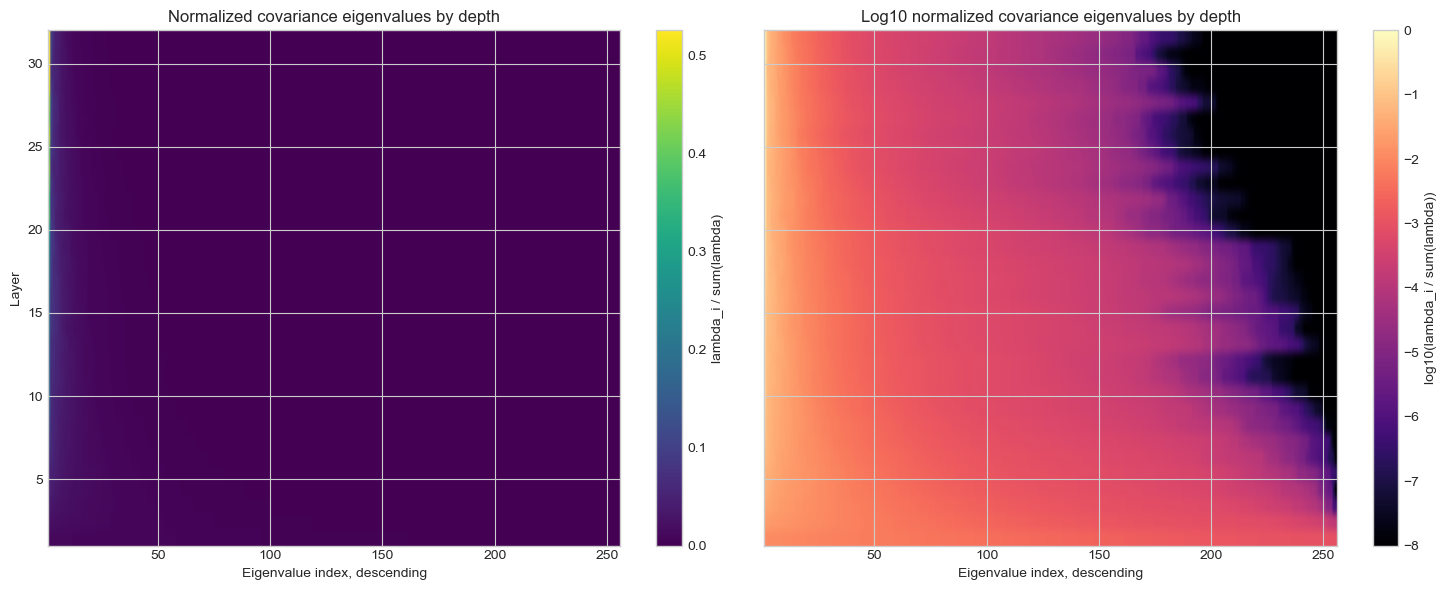

In [15]:
normalized_eigvals = eigvals_clipped / total_variance[:, None]
log_normalized = np.log10(np.maximum(normalized_eigvals, 1e-14))

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

im0 = axes[0].imshow(
    normalized_eigvals,
    aspect="auto",
    origin="lower",
    extent=[1, WIDTH, 1, DEPTH],
    cmap="viridis",
    vmin=0,
    vmax=float(np.max(normalized_eigvals)),
)
axes[0].set_title("Normalized covariance eigenvalues by depth")
axes[0].set_xlabel("Eigenvalue index, descending")
axes[0].set_ylabel("Layer")
cbar0 = fig.colorbar(im0, ax=axes[0])
cbar0.set_label("lambda_i / sum(lambda)")

im1 = axes[1].imshow(
    log_normalized,
    aspect="auto",
    origin="lower",
    extent=[1, WIDTH, 1, DEPTH],
    cmap="magma",
    vmin=-8,
    vmax=0,
)
axes[1].set_title("Log10 normalized covariance eigenvalues by depth")
axes[1].set_xlabel("Eigenvalue index, descending")
cbar1 = fig.colorbar(im1, ax=axes[1])
cbar1.set_label("log10(lambda_i / sum(lambda))")

fig.tight_layout()
plt.show()

## Selected Layer Spectra

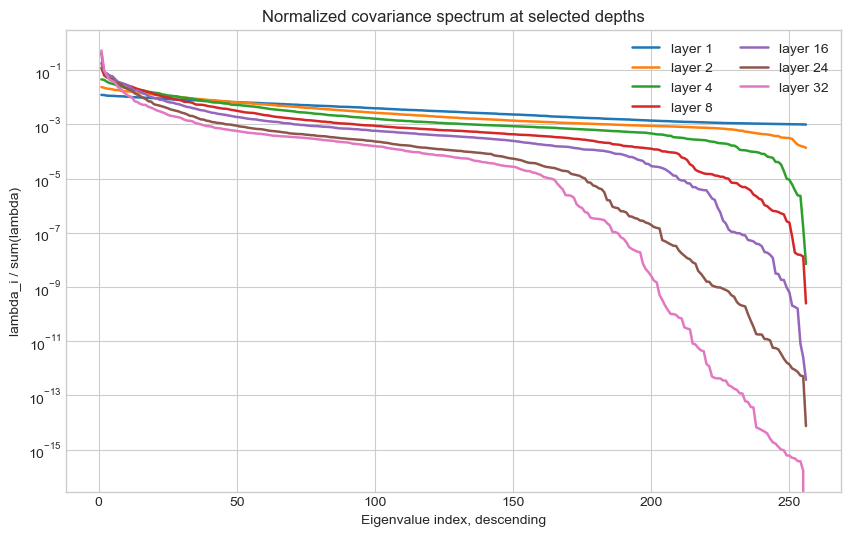

In [7]:
selected_layers = [1, 2, 4, 8, 16, 24, 32]

fig, ax = plt.subplots(figsize=(10, 6))
for layer in selected_layers:
    ax.plot(
        np.arange(1, WIDTH + 1),
        normalized_eigvals[layer - 1],
        label=f"layer {layer}",
        linewidth=1.8,
    )

ax.set_yscale("log")
ax.set_title("Normalized covariance spectrum at selected depths")
ax.set_xlabel("Eigenvalue index, descending")
ax.set_ylabel("lambda_i / sum(lambda)")
ax.legend(ncol=2)
plt.show()

## Rank Structure Versus Depth

Effective rank is entropy-based, participation ratio is inverse concentration, and numerical rank counts eigenvalues above `1e-8 * lambda_max`.

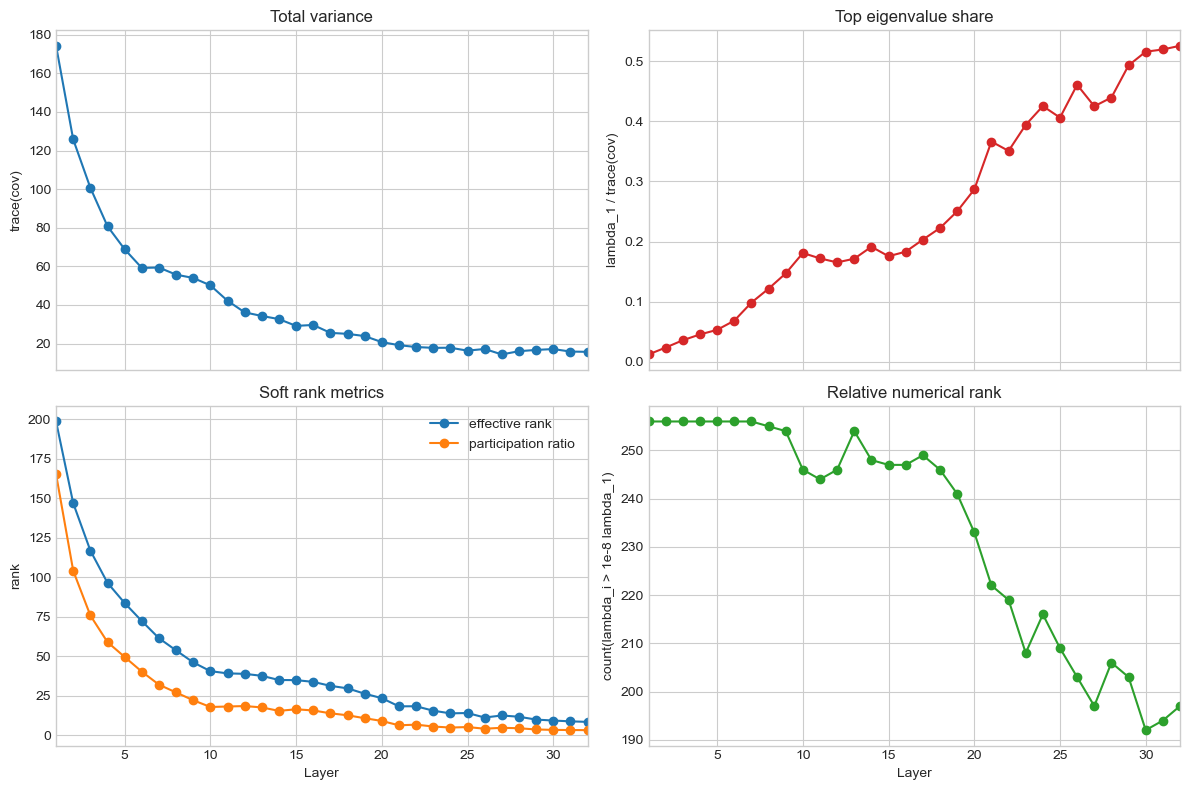

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)

axes[0, 0].plot(layers, total_variance, marker="o")
axes[0, 0].set_title("Total variance")
axes[0, 0].set_ylabel("trace(cov)")

axes[0, 1].plot(layers, top_share, marker="o", color="tab:red")
axes[0, 1].set_title("Top eigenvalue share")
axes[0, 1].set_ylabel("lambda_1 / trace(cov)")

axes[1, 0].plot(layers, effective_rank, marker="o", label="effective rank")
axes[1, 0].plot(layers, participation_ratio, marker="o", label="participation ratio")
axes[1, 0].set_title("Soft rank metrics")
axes[1, 0].set_xlabel("Layer")
axes[1, 0].set_ylabel("rank")
axes[1, 0].legend()

axes[1, 1].plot(layers, relative_numerical_rank, marker="o", color="tab:green")
axes[1, 1].set_title("Relative numerical rank")
axes[1, 1].set_xlabel("Layer")
axes[1, 1].set_ylabel("count(lambda_i > 1e-8 lambda_1)")

for ax in axes.flat:
    ax.set_xlim(1, DEPTH)

fig.tight_layout()
plt.show()

## How Many Directions Explain the Variance?

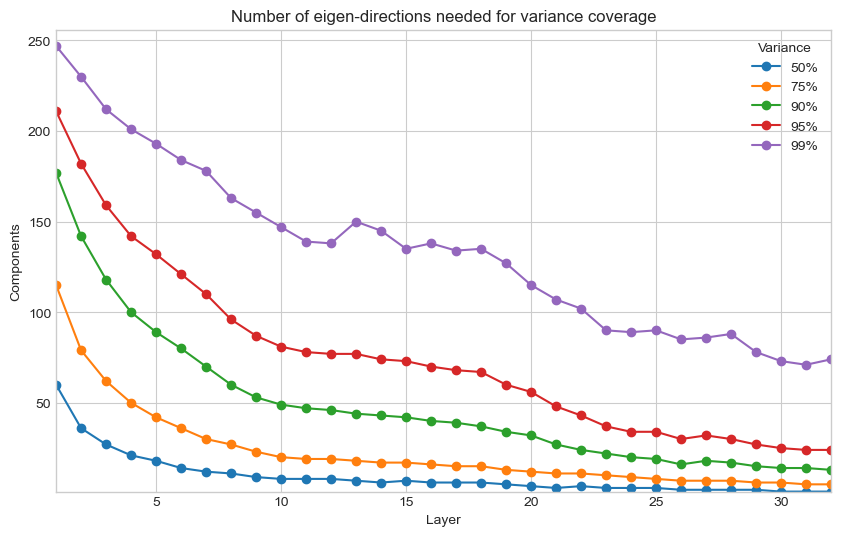

In [9]:
thresholds = [0.5, 0.75, 0.9, 0.95, 0.99]
components_for_threshold = {
    threshold: np.array([np.searchsorted(cumulative_share[i], threshold) + 1 for i in range(DEPTH)])
    for threshold in thresholds
}

fig, ax = plt.subplots(figsize=(10, 6))
for threshold, counts in components_for_threshold.items():
    ax.plot(layers, counts, marker="o", label=f"{threshold:.0%}")

ax.set_title("Number of eigen-directions needed for variance coverage")
ax.set_xlabel("Layer")
ax.set_ylabel("Components")
ax.set_xlim(1, DEPTH)
ax.set_ylim(1, WIDTH)
ax.legend(title="Variance")
plt.show()

## Inspect One Layer Directly

Change `LAYER_TO_INSPECT` to look at an individual covariance matrix and its eigenvalues.

Layer 32
trace:              15.729
top share:          0.525444
effective rank:     8.61
participation:      3.38
numerical rank:     197
top 10 eigenvalues: [8.2647 1.54   0.9943 0.6789 0.6315 0.5258 0.3672 0.332  0.2381 0.2034]


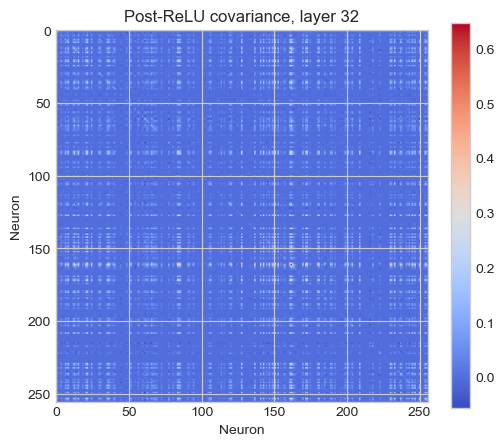

In [10]:
LAYER_TO_INSPECT = 32
idx = LAYER_TO_INSPECT - 1

print(f"Layer {LAYER_TO_INSPECT}")
print(f"trace:              {total_variance[idx]:.6g}")
print(f"top share:          {top_share[idx]:.6f}")
print(f"effective rank:     {effective_rank[idx]:.2f}")
print(f"participation:      {participation_ratio[idx]:.2f}")
print(f"numerical rank:     {relative_numerical_rank[idx]}")
print(f"top 10 eigenvalues: {eigvals_clipped[idx, :10]}")

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(covariances[idx], cmap="coolwarm")
ax.set_title(f"Post-ReLU covariance, layer {LAYER_TO_INSPECT}")
ax.set_xlabel("Neuron")
ax.set_ylabel("Neuron")
fig.colorbar(im, ax=ax)
plt.show()